#### Without Tuning Parameter

Generating Training Sequences...
Training Input Shape: (17631, 30, 13)
Generating Testing Sequences...
Testing Input Shape: (100, 30, 13)

Building LSTM Model...
Training LSTM... (This might take a minute)
Epoch 1/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 6299.5874 - val_loss: 4992.3384
Epoch 2/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 3002.1782 - val_loss: 1999.9349
Epoch 3/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1017.7231 - val_loss: 596.7209
Epoch 4/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 390.6464 - val_loss: 303.0494
Epoch 5/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 254.5089 - val_loss: 237.9450
Epoch 6/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 222.2769 - val_loss: 275.2747
Epoch 7/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 200.1050 - val_loss: 213.2388
Epoch 8/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 199.0804 - val_loss: 241.8284
Epoch 9/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 

,Metric,Train,Test,Training Time (s)
0,RMSE,12.767849,15.507894,51.921422
1,R2 Score,0.906653,0.850240,51.921422


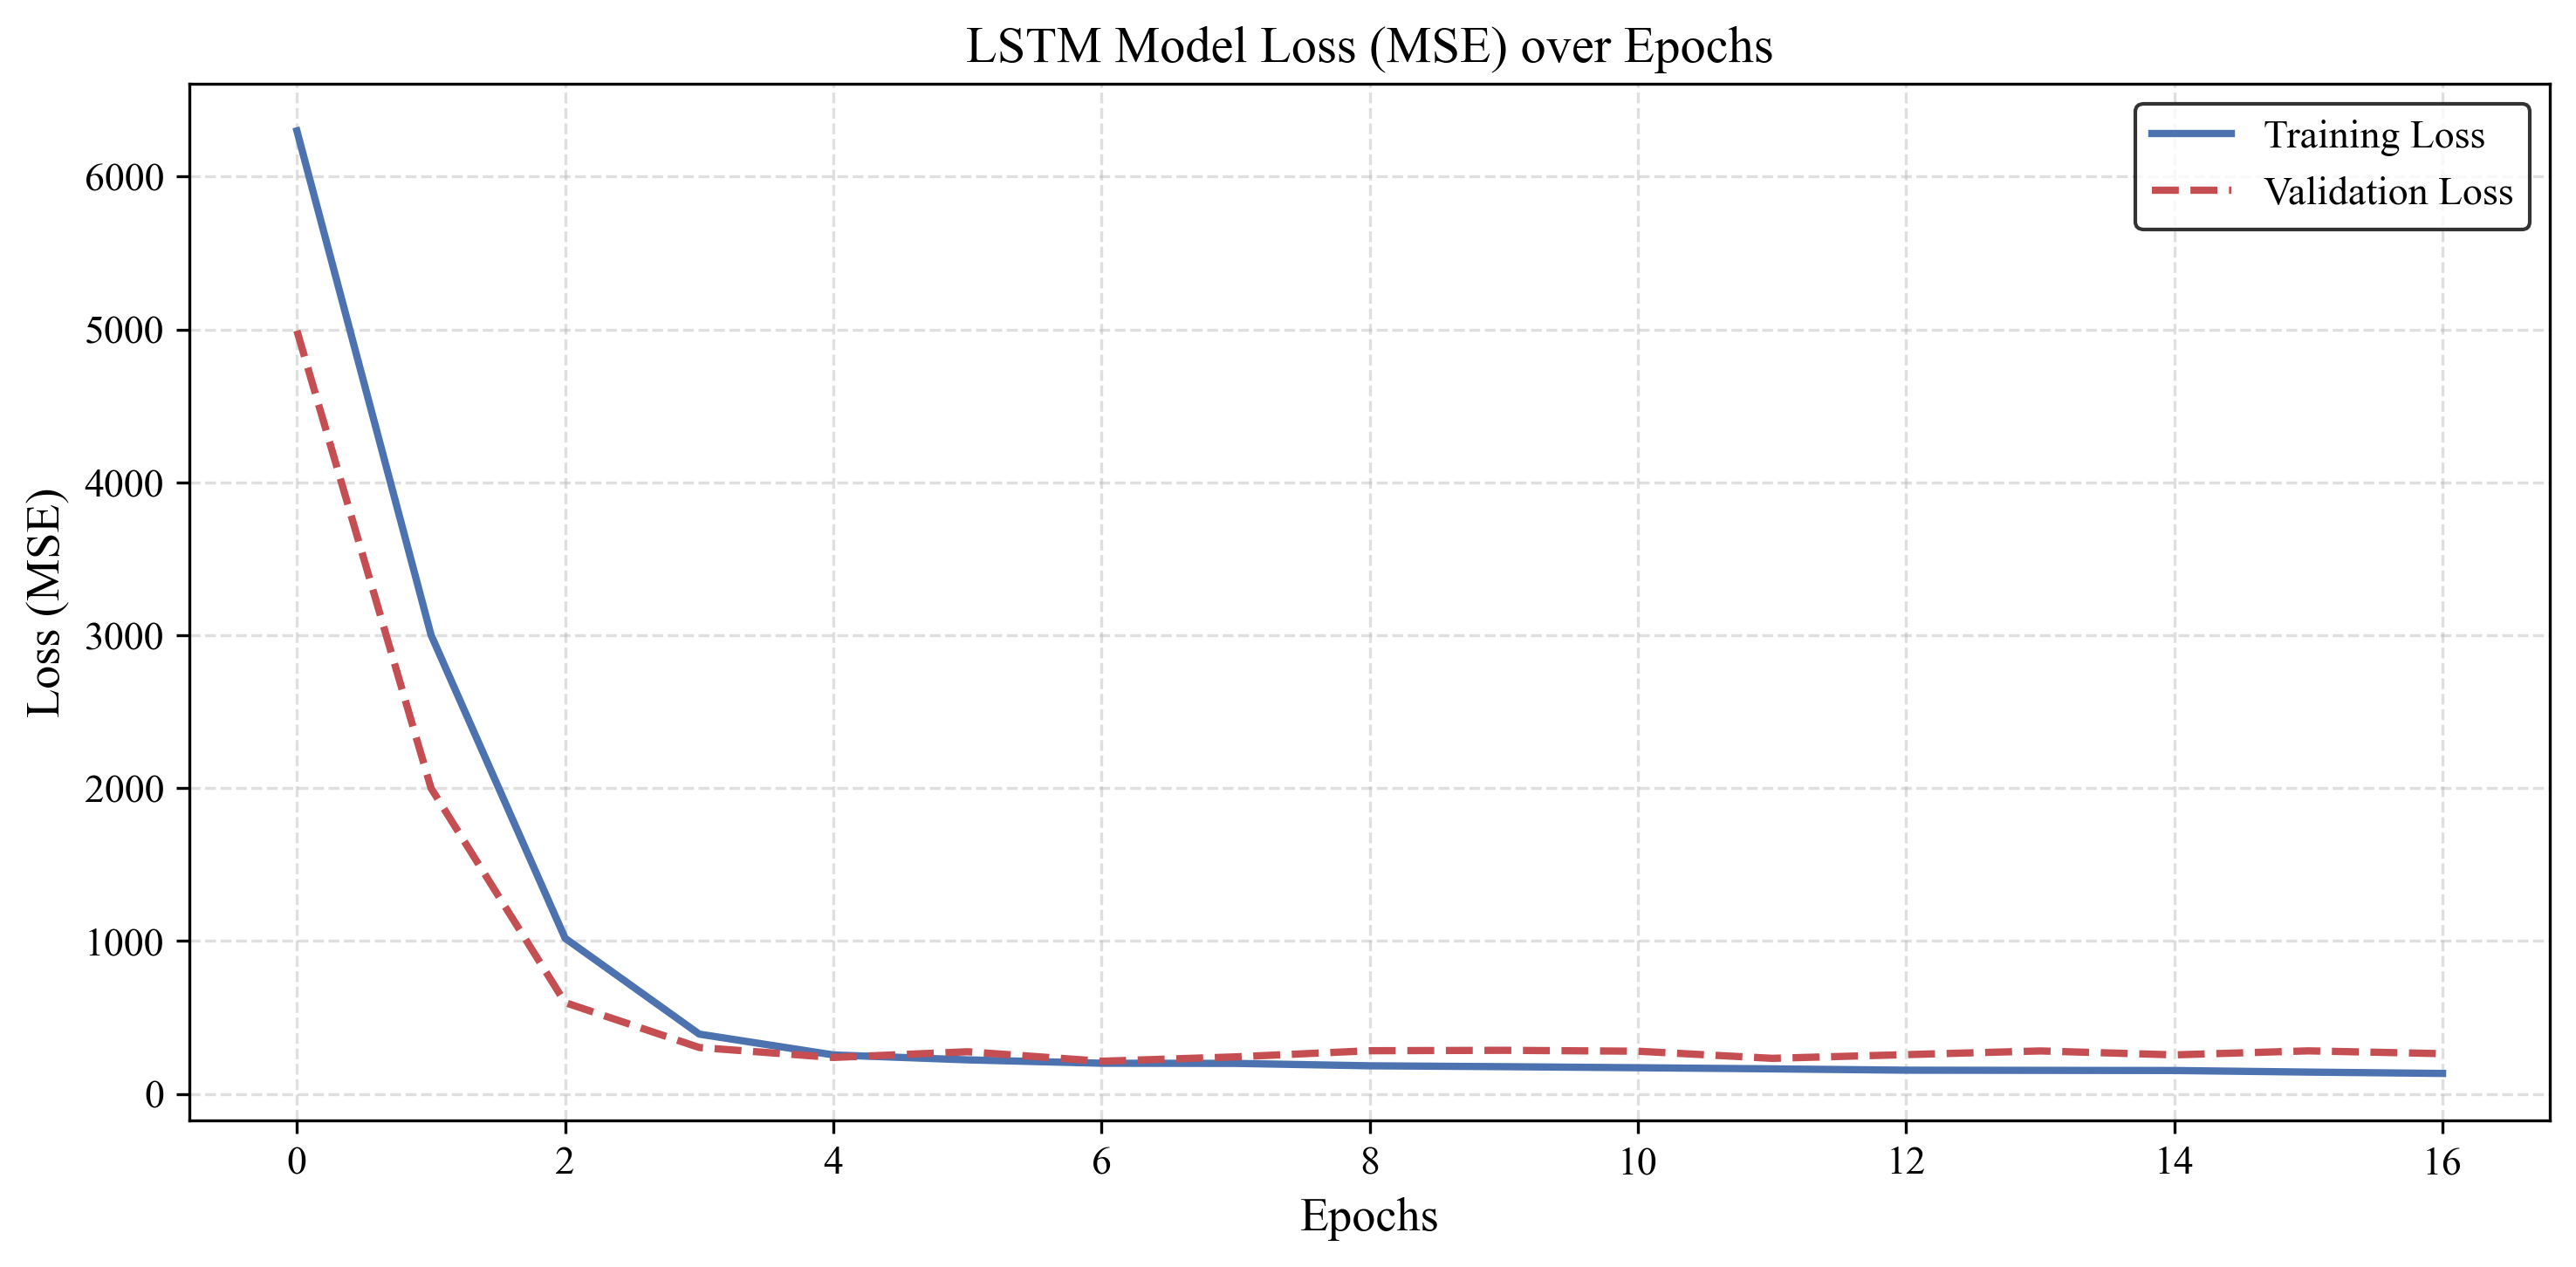

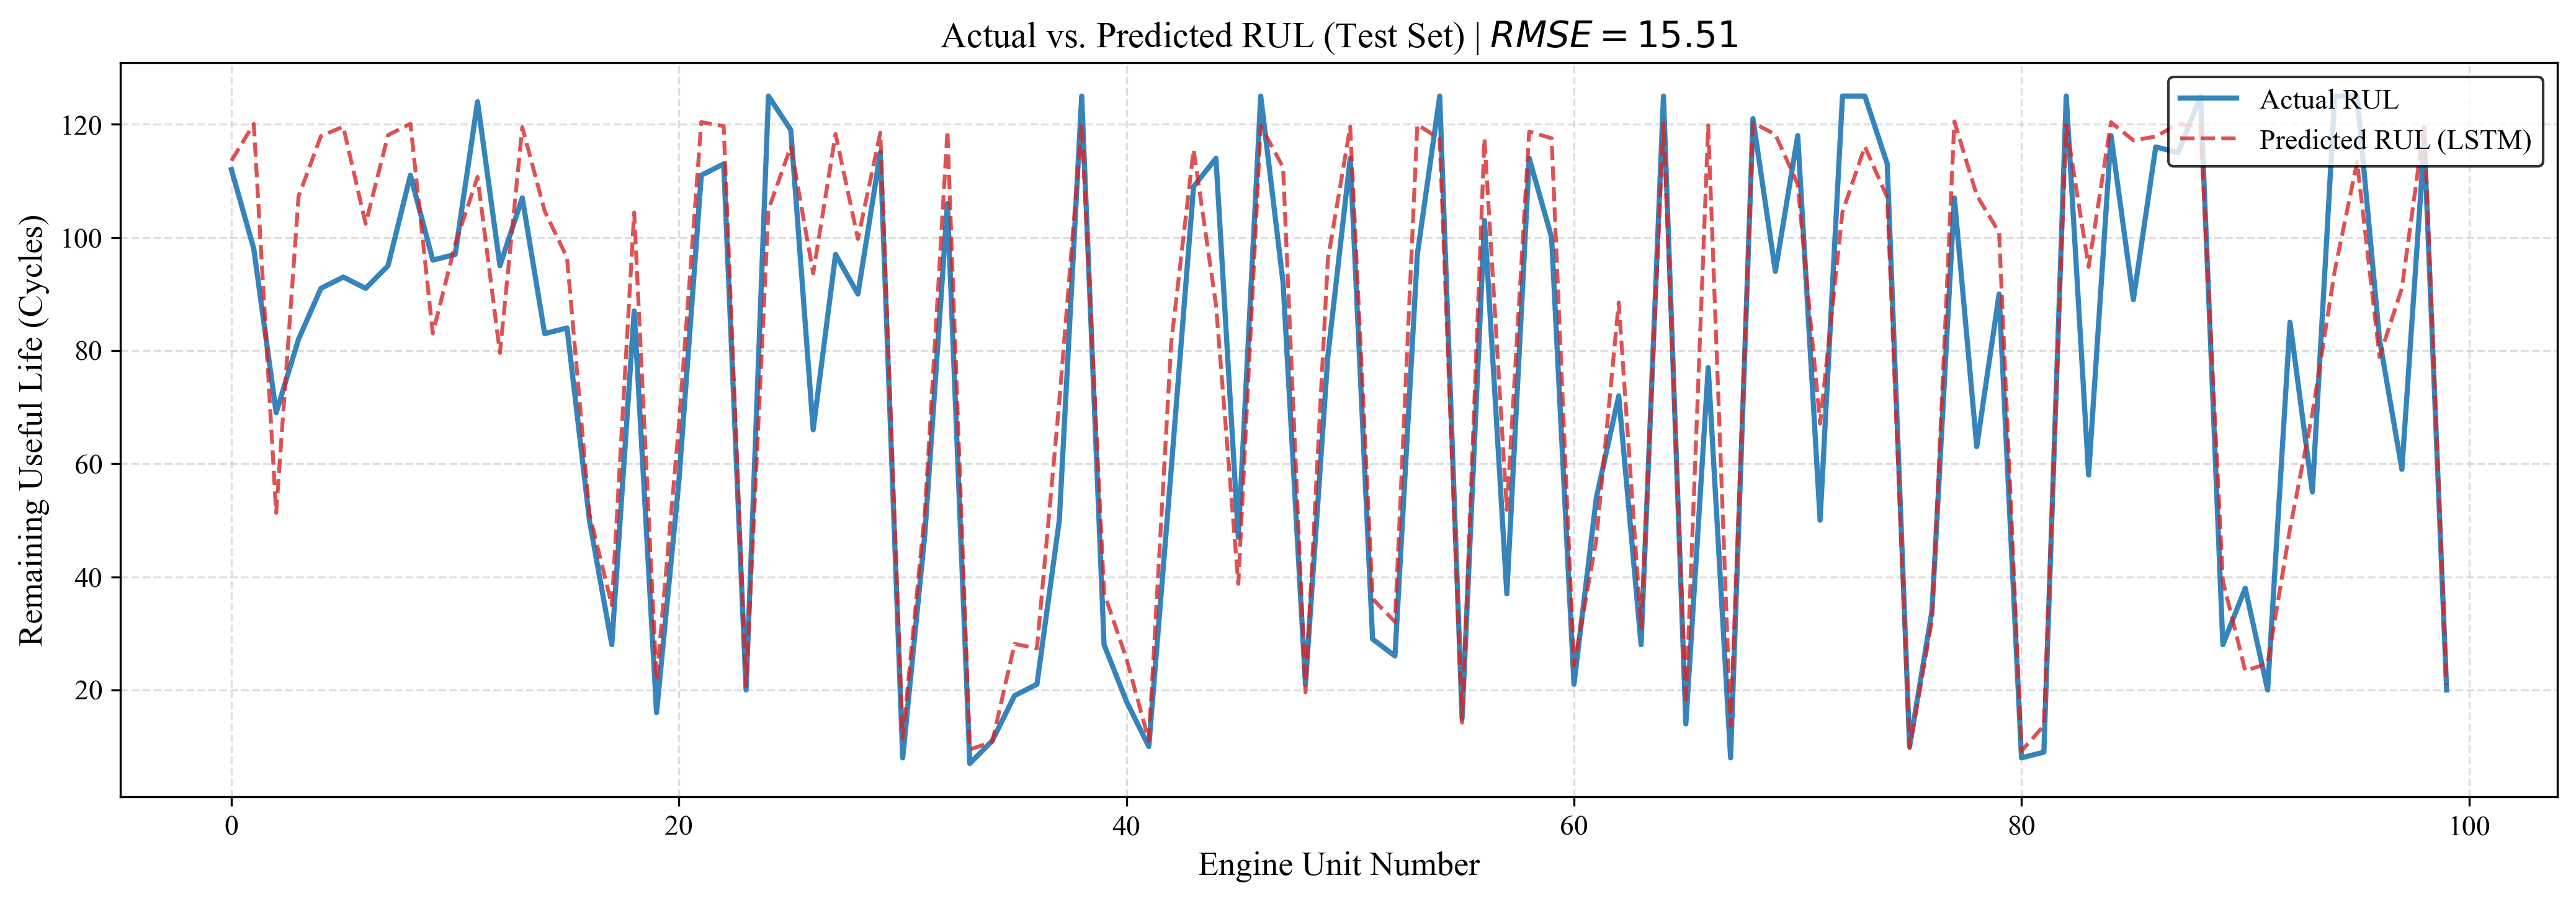

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + ['s_' + str(i) for i in range(1, 22)]
train = pd.read_csv('train_FD001.csv', delim_whitespace=True, header=None, names=columns)
test = pd.read_csv('test_FD001.csv', delim_whitespace=True, header=None, names=columns)
y_test_true = pd.read_csv('RUL_FD001.csv', delim_whitespace=True, header=None, names=['RUL'])

# 2. Preprocessing & Feature Selection
# Calculate RUL for Train
max_cycles = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']
train = train.merge(max_cycles, on='unit_nr', how='left')
train['RUL'] = train['max_cycle'] - train['time_cycles']
train.drop('max_cycle', axis=1, inplace=True)

# RUL Clipping (Crucial for C-MAPSS)
MAX_RUL = 125
train['RUL'] = train['RUL'].clip(upper=MAX_RUL)
y_test_true['RUL'] = y_test_true['RUL'].clip(upper=MAX_RUL)

# Drop constant columns and metadata
cols_to_drop = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 
                's_1', 's_5', 's_6', 's_10', 's_14', 's_16', 's_18', 's_19']

features = [c for c in train.columns if c not in cols_to_drop and c != 'RUL']

# Scale the data based on Train statistics
scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

# 3. Sequence Generation for LSTM (3D Data)
# The network needs data in the format: (samples, sequence_length, features)
sequence_length = 30 # Look back 30 cycles

def generate_sequences(df, seq_length, feature_cols):
    """Generates sliding windows of data for training."""
    seqs, labels = [], []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        feature_data = unit_data[feature_cols].values
        label_data = unit_data['RUL'].values
        
        # Slide a window over the engine's lifetime
        for i in range(len(unit_data) - seq_length):
            seqs.append(feature_data[i : i + seq_length])
            labels.append(label_data[i + seq_length])
            
    return np.array(seqs), np.array(labels)

print("Generating Training Sequences...")
X_train_seq, y_train_seq = generate_sequences(train, sequence_length, features)
print(f"Training Input Shape: {X_train_seq.shape}") # Expected: (Num_windows, 30, 14)

def generate_test_sequences(df, seq_length, feature_cols):
    """Extracts only the LAST sequence for each engine in the test set."""
    seqs = []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        feature_data = unit_data[feature_cols].values
        
        # If an engine has fewer cycles than sequence_length, pad it with zeros
        if len(feature_data) < seq_length:
            pad_length = seq_length - len(feature_data)
            padded_data = np.pad(feature_data, ((pad_length, 0), (0, 0)), mode='constant')
            seqs.append(padded_data)
        else:
            # Take the last 'seq_length' cycles
            seqs.append(feature_data[-seq_length:])
            
    return np.array(seqs)

print("Generating Testing Sequences...")
X_test_seq = generate_test_sequences(test, sequence_length, features)
y_test = y_test_true['RUL'].values
print(f"Testing Input Shape: {X_test_seq.shape}")

# 4. Build and Train LSTM Model
print("\nBuilding LSTM Model...")
model = Sequential()

# Layer 1: LSTM
model.add(LSTM(units=64, return_sequences=True, input_shape=(sequence_length, len(features))))
model.add(Dropout(0.2)) # Prevent overfitting

# Layer 2: LSTM
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Output Dense Layer
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='linear')) # Output layer for Regression

model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping stops training when validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

start_fit = time.time()
print("Training LSTM... (This might take a minute)")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=60,
    batch_size=128,
    validation_split=0.1, # Use 10% of train data for validation
    callbacks=[early_stop],
    verbose=1
)
end_fit = time.time() - start_fit

# 5. Evaluate and Visualize
print("\nGenerating Predictions...")
train_preds = model.predict(X_train_seq).flatten()
test_preds = model.predict(X_test_seq).flatten()

# Calculate Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_seq, train_preds))
train_r2 = r2_score(y_train_seq, train_preds)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'Train': [train_rmse, train_r2],
    'Test': [test_rmse, test_r2],
    'Training Time (s)': [end_fit, end_fit]  # Add training time to the metrics
})

print("\n--- LSTM Evaluation Matrix ---")
display(metrics_df)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,         # High resolution for print
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.facecolor": "white"  # Clean white background for journals
})

# Plot 1: Training and Validation Loss
fig1, ax1 = plt.subplots(figsize=(10, 5))

# Use distinct line styles for black & white print compatibility
ax1.plot(history.history['loss'], label='Training Loss', 
         color='#4C72B0', linewidth=2, linestyle='-')
ax1.plot(history.history['val_loss'], label='Validation Loss', 
         color='#C44E52', linewidth=2, linestyle='--')

ax1.set_title('LSTM Model Loss (MSE) over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')

# Add a clean bordered legend
ax1.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

# Plot 2: Actual vs Predicted RUL (Test Set)
fig2, ax2 = plt.subplots(figsize=(14, 5))

# Using the specific Blue and Red colors you preferred
color_actual = '#1f77b4'
color_pred = '#d62728'

# Actual RUL (Solid, slightly thicker line to establish the ground truth)
ax2.plot(y_test, label='Actual RUL', color=color_actual, alpha=0.9, linewidth=2)

# Predicted RUL (Dashed, slightly thinner so the actual line is still visible underneath)
ax2.plot(test_preds, label='Predicted RUL (LSTM)', 
         color=color_pred, alpha=0.8, linewidth=1.5, linestyle='--')

# Mathematical formatting for RMSE in the title
ax2.set_title(f'Actual vs. Predicted RUL (Test Set) | $RMSE = {test_rmse:.2f}$')
ax2.set_xlabel('Engine Unit Number')
ax2.set_ylabel('Remaining Useful Life (Cycles)')

# Add a clean bordered legend
ax2.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('lstm_rul_predictions.pdf', format='pdf', bbox_inches='tight') # Uncomment to save
plt.show()

#### With Tuning Parameter

Generating Sequences...

Building Improved Stacked LSTM Architecture...
Training Model...
Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 3187.3718 - val_loss: 585.6973 - learning_rate: 0.0010
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 385.3357 - val_loss: 297.7064 - learning_rate: 0.0010
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 241.9770 - val_loss: 175.6616 - learning_rate: 0.0010
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 212.4033 - val_loss: 179.7762 - learning_rate: 0.0010
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 203.7767 - val_loss: 255.0621 - learning_rate: 0.0010
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 198.5831
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 199.2275 - val_loss: 179.5432 - learning_rate: 0.0010
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 173.9921 - v

,Metric,Train,Test,Training Time (s)
0,RMSE,10.858696,12.656213,180.893323
1,R2 Score,0.931958,0.900253,180.893323


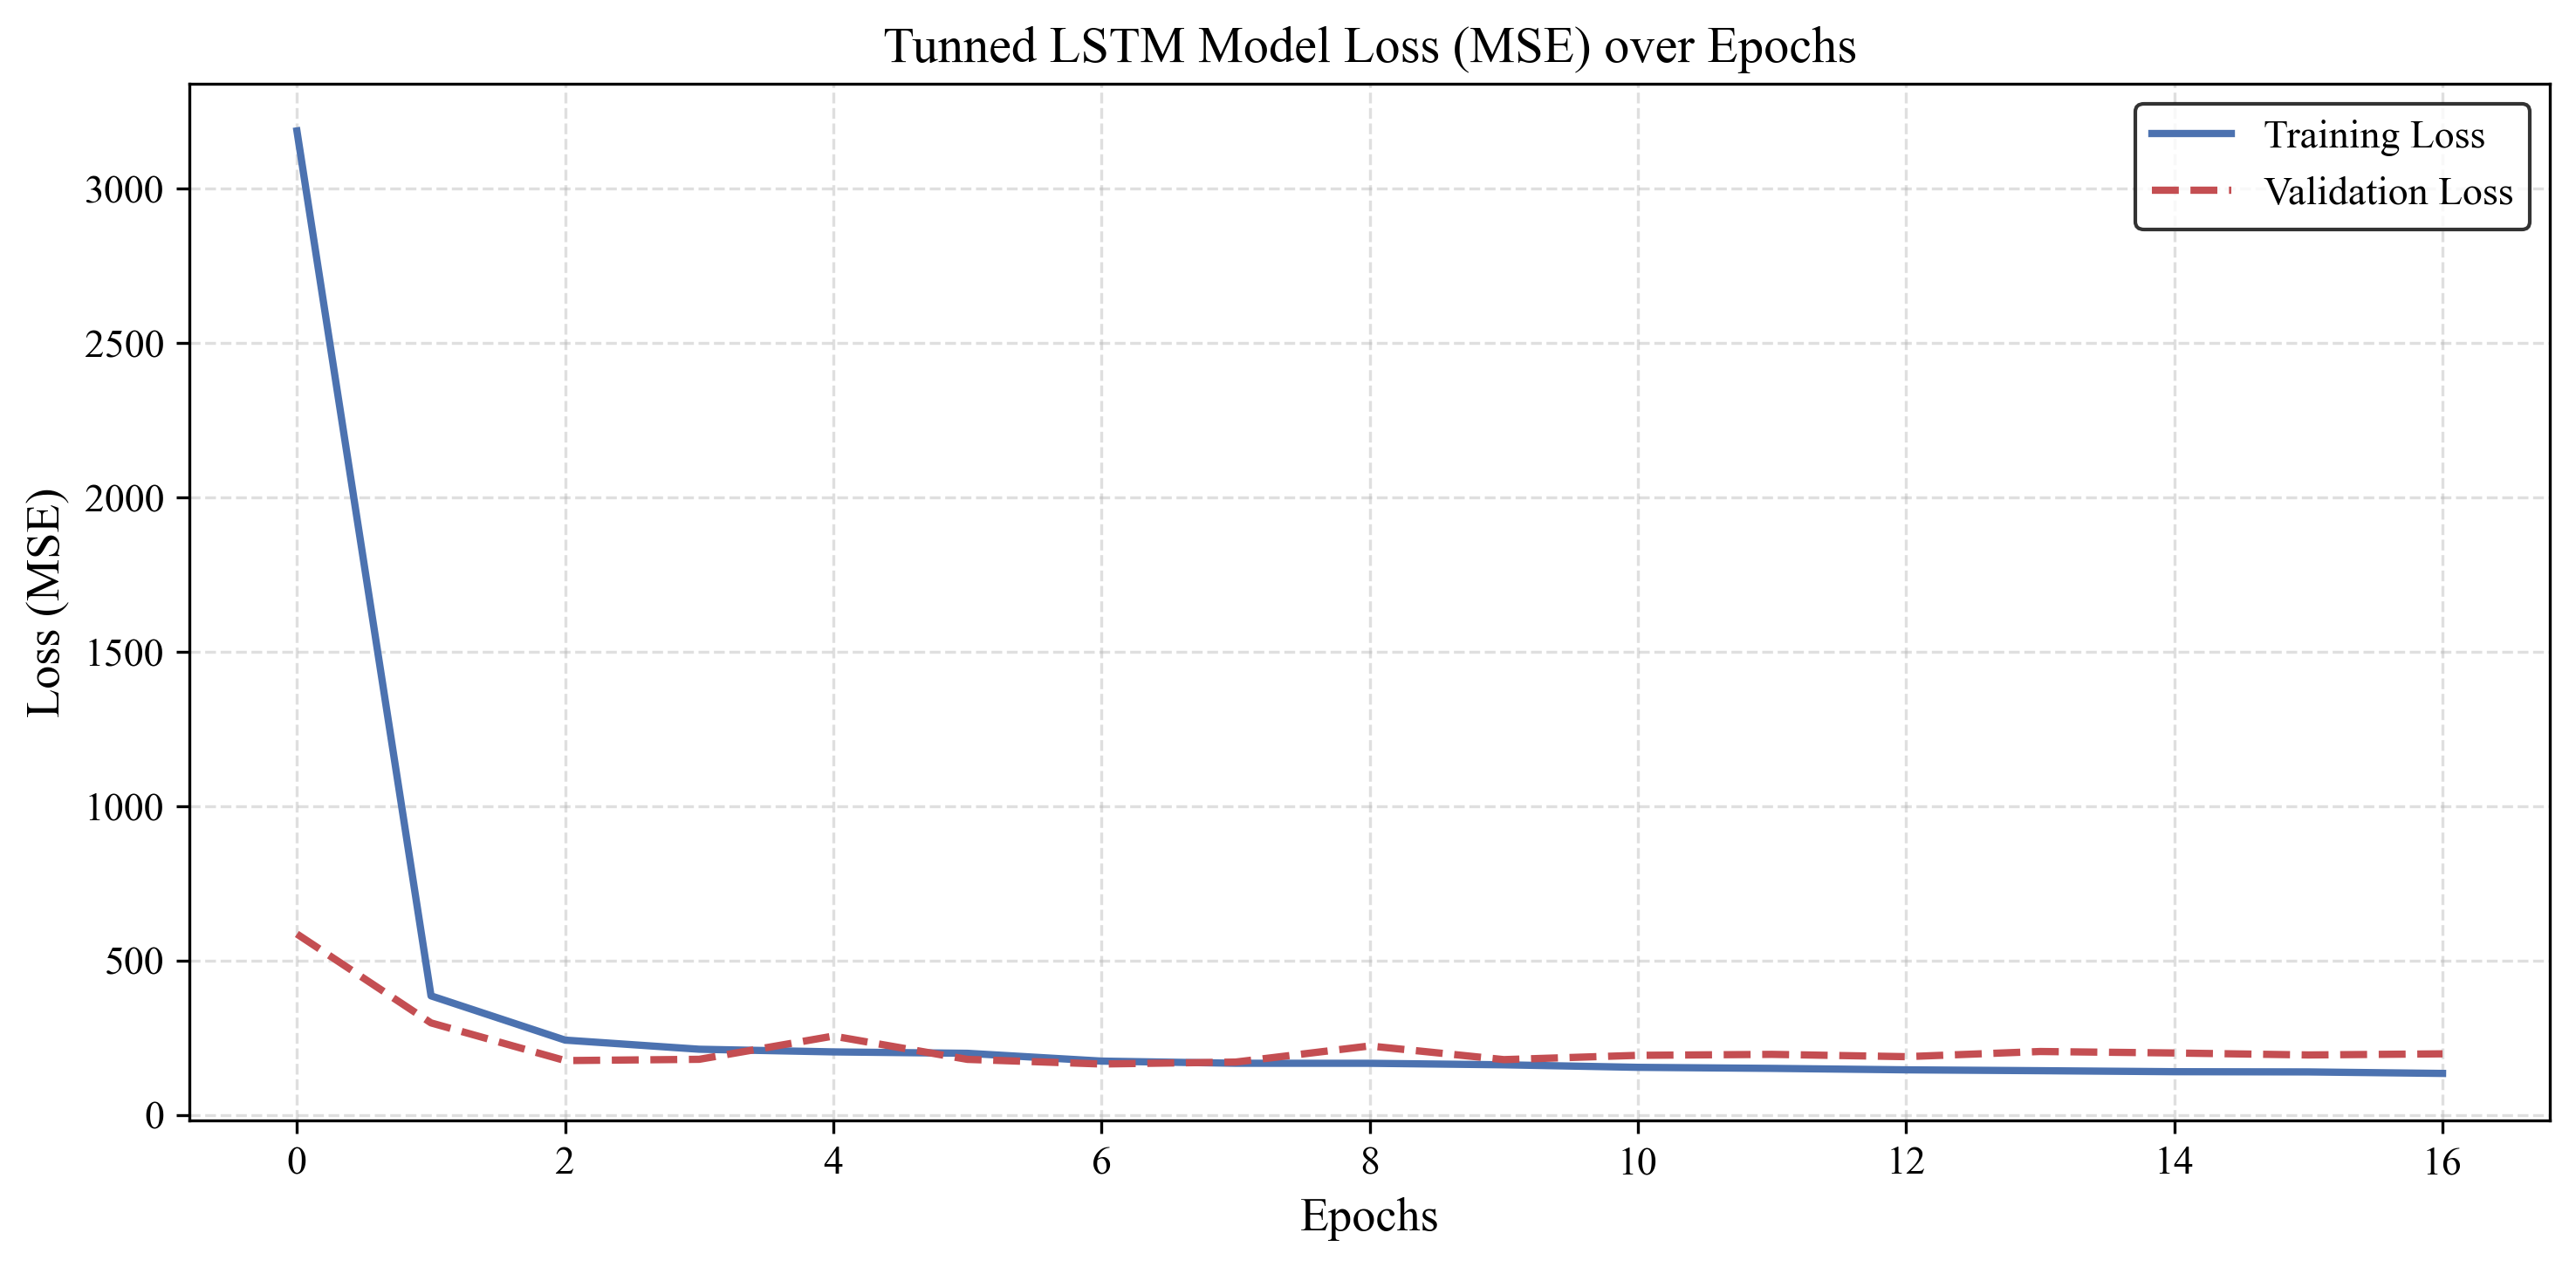

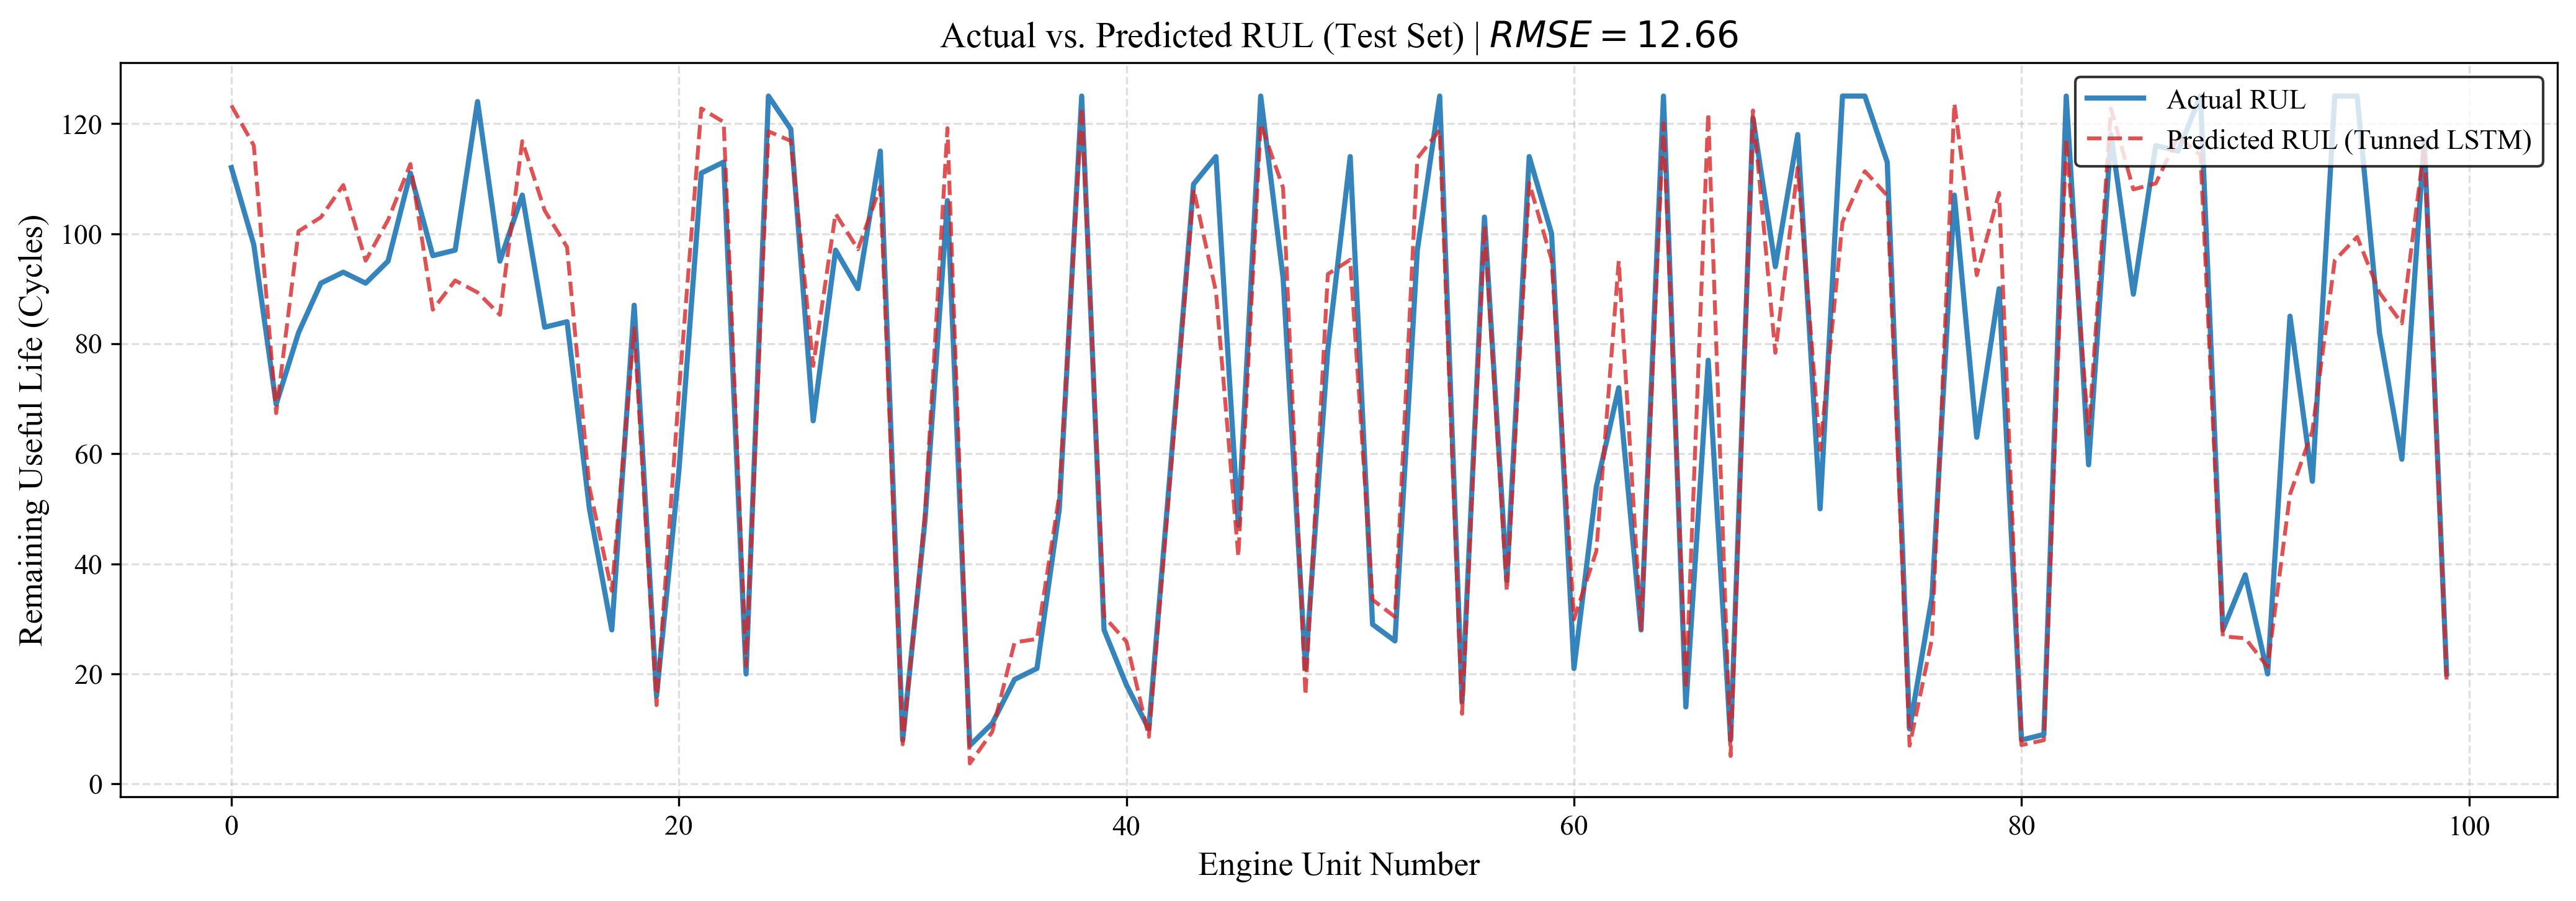


Model successfully saved as 'Remaining_Useful_Life_lstm_model.keras'


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + ['s_' + str(i) for i in range(1, 22)]
train = pd.read_csv('train_FD001.csv', delim_whitespace=True, header=None, names=columns)
test = pd.read_csv('test_FD001.csv', delim_whitespace=True, header=None, names=columns)
y_test_true = pd.read_csv('RUL_FD001.csv', delim_whitespace=True, header=None, names=['RUL'])

# 2. Preprocessing 
# Calculate RUL for Train
max_cycles = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']
train = train.merge(max_cycles, on='unit_nr', how='left')
train['RUL'] = train['max_cycle'] - train['time_cycles']
train.drop('max_cycle', axis=1, inplace=True)

# RUL Clipping (125 is the optimal threshold for FD001)
MAX_RUL = 125
train['RUL'] = train['RUL'].clip(upper=MAX_RUL)
y_test_true['RUL'] = y_test_true['RUL'].clip(upper=MAX_RUL)

cols_to_drop = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 
                's_1', 's_5', 's_6', 's_10', 's_14', 's_16', 's_18', 's_19']
features = [c for c in train.columns if c not in cols_to_drop and c != 'RUL']

# Scale the data (Raw features only, no EWMA smoothing)
scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

# 3. Sequence Generation (Increased to 40 Cycles)
sequence_length = 40 # Increased memory window

def generate_sequences(df, seq_length, feature_cols):
    seqs, labels = [], []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        feature_data = unit_data[feature_cols].values
        label_data = unit_data['RUL'].values
        for i in range(len(unit_data) - seq_length):
            seqs.append(feature_data[i : i + seq_length])
            labels.append(label_data[i + seq_length])
    return np.array(seqs), np.array(labels)

def generate_test_sequences(df, seq_length, feature_cols):
    seqs = []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        feature_data = unit_data[feature_cols].values
        if len(feature_data) < seq_length:
            pad_length = seq_length - len(feature_data)
            padded_data = np.pad(feature_data, ((pad_length, 0), (0, 0)), mode='constant')
            seqs.append(padded_data)
        else:
            seqs.append(feature_data[-seq_length:])
    return np.array(seqs)

print("Generating Sequences...")
X_train_seq, y_train_seq = generate_sequences(train, sequence_length, features)
X_test_seq = generate_test_sequences(test, sequence_length, features)
y_test = y_test_true['RUL'].values

# 4. Build Highly-Regularized Stacked LSTM
print("\nBuilding Improved Stacked LSTM Architecture...")
model = Sequential()

# Layer 1: LSTM with heavy L2 Regularization on both weights and recurrent steps
model.add(LSTM(
    units=128, 
    return_sequences=True, 
    input_shape=(sequence_length, len(features)),
    kernel_regularizer=l2(1e-4),
    recurrent_regularizer=l2(1e-4)
))
model.add(Dropout(0.3))

# Layer 2: LSTM
model.add(LSTM(
    units=64, 
    return_sequences=False,
    kernel_regularizer=l2(1e-4),
    recurrent_regularizer=l2(1e-4)
))
model.add(Dropout(0.3))

# Output Layers
model.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(Dense(1, activation='linear'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

start_fit = time.time()
# Train the Model
print("Training Model...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100, 
    batch_size=64, 
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
end_fit = time.time() - start_fit


# 5. Evaluate and Visualize
print("\nGenerating Predictions...")
train_preds = model.predict(X_train_seq).flatten()
test_preds = model.predict(X_test_seq).flatten()

# Calculate Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_seq, train_preds))
train_r2 = r2_score(y_train_seq, train_preds)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'Train': [train_rmse, train_r2],
    'Test': [test_rmse, test_r2],
    'Training Time (s)': [end_fit, end_fit]  # Add training time to the metrics
})

print("\n--- Final Improved LSTM Evaluation Matrix ---")
display(metrics_df)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,         # High resolution for print
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.facecolor": "white"  # Clean white background for journals
})

# Plot 1: Training and Validation Loss
fig1, ax1 = plt.subplots(figsize=(10, 5))

# Use distinct line styles for black & white print compatibility
ax1.plot(history.history['loss'], label='Training Loss', 
         color='#4C72B0', linewidth=2, linestyle='-')
ax1.plot(history.history['val_loss'], label='Validation Loss', 
         color='#C44E52', linewidth=2, linestyle='--')

ax1.set_title('Tunned LSTM Model Loss (MSE) over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')

# Add a clean bordered legend
ax1.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
# plt.savefig('lstm_loss_curve.pdf', format='pdf', bbox_inches='tight') # Uncomment to save
plt.show()

# Plot 2: Actual vs Predicted RUL (Test Set)
fig2, ax2 = plt.subplots(figsize=(14, 5))

# Using the specific Blue and Red colors you preferred
color_actual = '#1f77b4'
color_pred = '#d62728'

# Actual RUL (Solid, slightly thicker line to establish the ground truth)
ax2.plot(y_test, label='Actual RUL', color=color_actual, alpha=0.9, linewidth=2)

# Predicted RUL (Dashed, slightly thinner so the actual line is still visible underneath)
ax2.plot(test_preds, label='Predicted RUL (Tunned LSTM)', 
         color=color_pred, alpha=0.8, linewidth=1.5, linestyle='--')

# Mathematical formatting for RMSE in the title
ax2.set_title(f'Actual vs. Predicted RUL (Test Set) | $RMSE = {test_rmse:.2f}$')
ax2.set_xlabel('Engine Unit Number')
ax2.set_ylabel('Remaining Useful Life (Cycles)')

# Add a clean bordered legend
ax2.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('lstm_rul_predictions_tunned.pdf', format='pdf', bbox_inches='tight') # Uncomment to save
plt.show()

# Save the model using the modern Keras format
model.save('Remaining_Useful_Life_lstm_model.keras')
print("\nModel successfully saved as 'Remaining_Useful_Life_lstm_model.keras'")

In [7]:
import joblib

# 1. Save the Scaler
# It is CRITICAL to save the scaler so live data is scaled exactly like the training data!
joblib.dump(scaler, 'sensor_scaler_RUL.pkl')
print("Scaler saved as 'sensor_scaler_RUL.pkl'")

Scaler saved as 'sensor_scaler_RUL.pkl'
